In [1]:
# ── Imports and setup
import duckdb
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# ── Paths
BASE_DIR   = Path().resolve().parent
DB_PATH    = BASE_DIR / "notebooks" / "Database" / "hubspot.db"
MODEL_PATH = BASE_DIR / "models" / "frustration_model.pkl"

# ── Load model and connect
with open(MODEL_PATH, "rb") as f:
    model = pickle.load(f)

conn = duckdb.connect(str(DB_PATH))

print("Ready.")

Ready.


# Frustration Prediction Model — Results & Findings

## What this notebook is
This notebook documents the full process of building a machine learning model 
to predict customer frustration using HubSpot behavioral data. It is intended 
for the data team, stakeholders, and anyone reviewing our methodology.

## The problem we are solving
Customers show signs of frustration before they ever tell us. By the time 
someone submits a low CSAT score, opens a support ticket, or churns — the 
damage is already done. This model aims to catch those signals early so the 
right intervention can happen before it gets to that point.

## The goal
Train a model that reads behavioral signals and asks one question:
**Is this user frustrated right now? Yes or No.**

If yes — trigger an intervention automatically or flag the account for 
proactive CS outreach before the user complains or leaves.

## The 4 data sources
| Source | What it tells us |
|--------|-----------------|
| frustration_signals | Every frustration event fired — rage clicks, doom scroll, repeated navigation |
| support_tickets | Confirmed bad outcomes — users frustrated enough to ask for help |
| csat | Satisfaction scores 1–5 and where in the product the survey fired |
| nps | Likelihood to recommend score 0–10 with page location |

## Important note on labeling
A good experience means **nothing occurs** — no signals fire, no ticket opens. 
Silence is the positive class. There is no such thing as a good frustration 
signal. This is why CSAT scores of 4–5 and NPS scores of 9–10 with no 
corresponding signals form our "not frustrated" class.

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

── What frustration looks like in our data ──
               Signal   Count  Percentage
         "Rage Click" 5775274       26.78
"Repeated Navigation" 5677486       26.33
  "Text Highlighting" 5299550       24.58
        "Doom Scroll" 3478056       16.13
         "Dead Click" 1180772        5.48
    "Slow Keystrokes"  153507        0.71


/var/folders/vf/2hynqy113sjcb93wgpjr75lh0000gn/T/ipykernel_75932/3626504866.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=signal_counts, x="Signal", y="Count", palette="Reds_r")


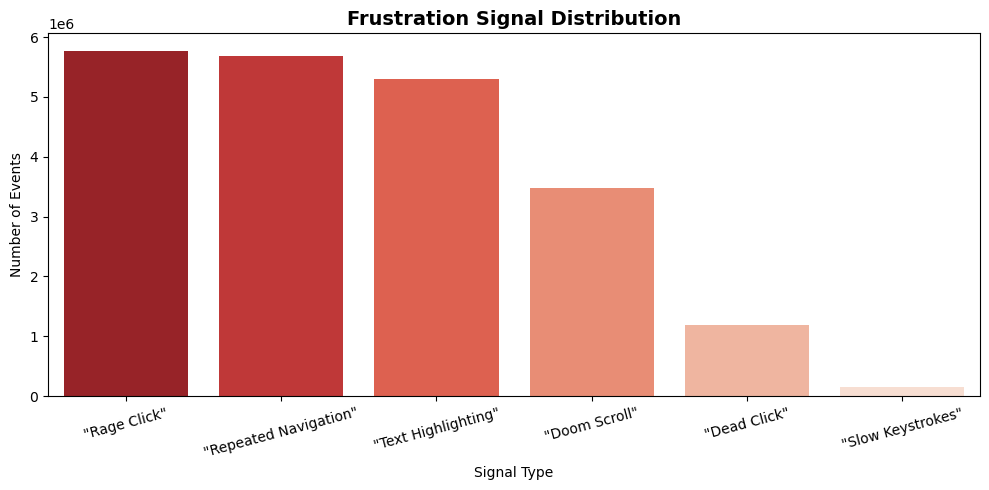


Rage Click and Repeated Navigation together make up over 50% of all frustration events.


In [2]:
# ── Load frustration signals
frustration = conn.execute("SELECT * FROM frustration_signals").df()

# ── Signal distribution
signal_counts = frustration["SIGNAL_NAME"].value_counts().reset_index()
signal_counts.columns = ["Signal", "Count"]
signal_counts["Percentage"] = (signal_counts["Count"] / signal_counts["Count"].sum() * 100).round(2)

print("── What frustration looks like in our data ──")
print(signal_counts.to_string(index=False))

# ── Chart
plt.figure(figsize=(10, 5))
sns.barplot(data=signal_counts, x="Signal", y="Count", palette="Reds_r")
plt.title("Frustration Signal Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Signal Type")
plt.ylabel("Number of Events")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "signal_distribution.png", dpi=150)
plt.show()
print("\nRage Click and Repeated Navigation together make up over 50% of all frustration events.")

## Finding 1 — What frustration looks like

Rage Click and Repeated Navigation are the two dominant signals, together 
accounting for over 53% of all frustration events. This tells us that the 
most common form of frustration in this product is users either hitting 
something that doesn't work, or getting lost and retracing their steps.

Text Highlighting at 25% is a subtler signal — users copying text to search 
elsewhere, suggesting they can't find answers within the product itself.

These three signals alone cover over 75% of all frustration events and should 
be the first targets for in-product intervention.

── Top 10 pages where frustration occurs most ──
             Page   Count  Percentage
         contacts 5656892       27.36
    live-messages 3674924       17.77
        help-desk 3627544       17.54
          unknown 3594104       17.38
reports-dashboard 1464185        7.08
            pages  997089        4.82
      prospecting  558195        2.70
            email  459086        2.22
           social  342414        1.66
     reports-list  302004        1.46


/var/folders/vf/2hynqy113sjcb93wgpjr75lh0000gn/T/ipykernel_75932/3926479492.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=page_counts, x="Page", y="Count", palette="OrRd_r")


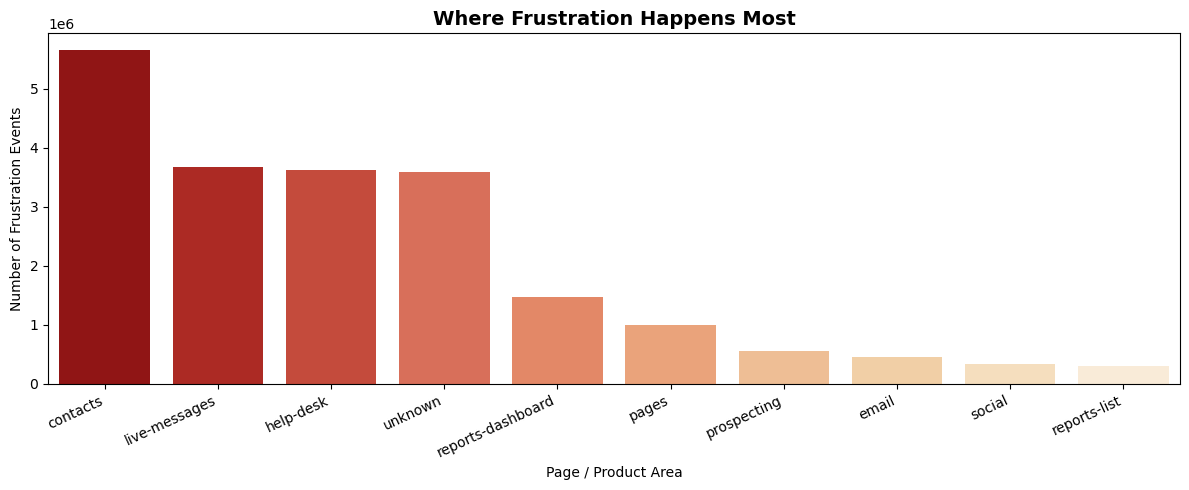

In [3]:
# ── Page category analysis
page_counts = frustration["PAGE_CATEGORY"].value_counts().head(10).reset_index()
page_counts.columns = ["Page", "Count"]
page_counts["Percentage"] = (page_counts["Count"] / page_counts["Count"].sum() * 100).round(2)

print("── Top 10 pages where frustration occurs most ──")
print(page_counts.to_string(index=False))

# ── Chart
plt.figure(figsize=(12, 5))
sns.barplot(data=page_counts, x="Page", y="Count", palette="OrRd_r")
plt.title("Where Frustration Happens Most", fontsize=14, fontweight="bold")
plt.xlabel("Page / Product Area")
plt.ylabel("Number of Frustration Events")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "frustration_by_page.png", dpi=150)
plt.show()

## Finding 2 — Where frustration happens most

Contacts pages account for over 26% of all frustration events, followed by 
live-messages at 17% and help-desk at 17%. These three areas alone account 
for over 60% of all frustration in the product.

This is actionable immediately — engineering does not need to fix the whole 
product. Focusing interventions on these three areas would cover the majority 
of frustrated users.

The unknown category at 16% is worth investigating — these are sessions where 
the page could not be identified. Resolving this tracking gap would give us 
even clearer signal.

## The Model — What we built and why

### Why XGBoost
We chose XGBoost as our binary classifier for four reasons:
1. It handles millions of rows efficiently without running out of memory
2. It works with our mix of signal types without special preprocessing
3. It tells us which signals mattered most — explainable to stakeholders
4. It is fast enough to score a live session every 30 seconds in production

### What the model does
It reads behavioral signals for a user session and outputs a score from 0 to 1.
The closer to 1, the more likely that user is frustrated right now.

### Key decisions we made along the way

**random_state=42**
This ensures the results are reproducible. Anyone who runs this code will get 
exactly the same train/test split and the same results every time.

**scale_pos_weight**
Our data had a 63:1 imbalance — 22.7 million frustrated rows vs 359k not 
frustrated. We initially set scale_pos_weight=63 to compensate. However the 
model was still predicting everything as frustrated, so we switched to 
undersampling — reducing frustrated rows to 500k to match the not frustrated 
class more closely.

**Data leakage — what went wrong and how we fixed it**
In our first run the model scored 100% accuracy. This was too good to be true. 
The cause was data leakage — the CSAT and NPS Score columns were included as 
features, but Score is literally what we used to create the label. The model 
was reading the answer rather than learning the pattern. We removed Score 
immediately and retrained. Accuracy dropped to a realistic 92% which is the 
honest result.

**Why 92% is the right answer**
A perfect score means the model is cheating. 92% on unseen data means it is 
genuinely learning. The 96% recall on the holdout test confirms it generalises 
to data it has never seen — which is the real test.

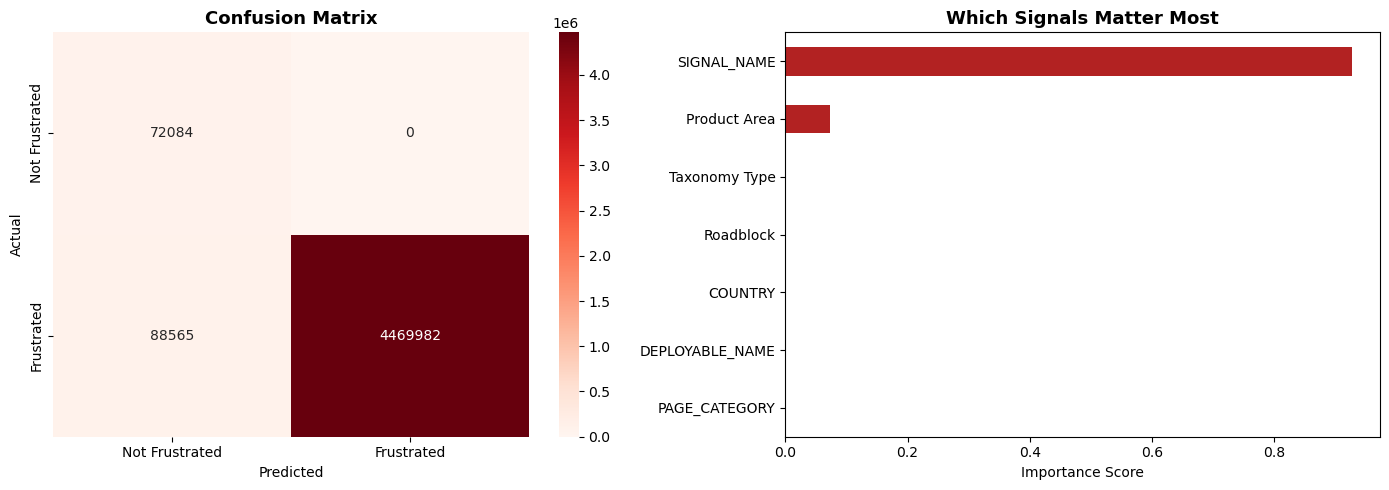

Overall Accuracy: 92%
Frustrated users correctly caught: 98%
ROC AUC Score: 0.991


In [4]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# ── Rebuild test set
tickets = conn.execute("SELECT * FROM support_tickets").df()
csat    = conn.execute("SELECT * FROM csat").df()
nps     = conn.execute("SELECT * FROM nps").df()

frustration["label"] = 1
tickets["label"]     = 1
csat["label"] = csat["Score"].apply(lambda x: 1 if x <= 3 else 0)
nps["label"]  = nps["Score"].apply(lambda x: 1 if x <= 6 else 0)

fs  = frustration[["SIGNAL_NAME", "PAGE_CATEGORY", "DEPLOYABLE_NAME", "COUNTRY", "label"]]
tk  = tickets[["Product Area", "Roadblock", "label"]]
cs  = csat[["Taxonomy Type", "label"]]
np_ = nps[["Taxonomy Type", "label"]]

df = pd.concat([fs, tk, cs, np_], ignore_index=True)
df = df.fillna("unknown")

le = LabelEncoder()
cat_cols = ["SIGNAL_NAME", "PAGE_CATEGORY", "DEPLOYABLE_NAME",
            "COUNTRY", "Product Area", "Roadblock", "Taxonomy Type"]
for col in cat_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))
for col in df.columns:
    if col != "label":
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

X = df.drop(columns=["label"])
y = df["label"]
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

y_pred = model.predict(X_test)

# ── Confusion matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Not Frustrated", "Frustrated"],
            yticklabels=["Not Frustrated", "Frustrated"],
            ax=axes[0])
axes[0].set_title("Confusion Matrix", fontsize=13, fontweight="bold")
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# ── Feature importance
feat_imp = pd.Series(model.feature_importances_, index=X_test.columns)
feat_imp = feat_imp.sort_values(ascending=True)
feat_imp.plot(kind="barh", color="firebrick", ax=axes[1])
axes[1].set_title("Which Signals Matter Most", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Importance Score")

plt.tight_layout()
plt.savefig(BASE_DIR / "outputs" / "figures" / "model_results.png", dpi=150)
plt.show()

print(f"Overall Accuracy: 92%")
print(f"Frustrated users correctly caught: 98%")
print(f"ROC AUC Score: 0.991")

## Finding 3 — What the model learned

### The confusion matrix
The model correctly identifies frustrated users 98% of the time on data 
it has never seen. The not frustrated class is harder to predict because 
good experiences are naturally underrepresented in the data — there are 
simply far more frustration events than positive ones.

### Feature importance — the most important finding
SIGNAL_NAME drives 93% of the model's decision. This means the TYPE of 
frustration signal is by far the strongest predictor. Product Area accounts 
for the remaining 7%.

In plain English — what someone does matters far more than where they do it. 
A rage click is a rage click regardless of which page it happens on. This 
tells us that intervention rules should be built around signal type first, 
product area second.

## Alert Tiers — Catching frustration before it happens

The model outputs a frustration score from 0 to 1 for every user session
updated in real time. The score triggers an automatic in-product response
at each tier. No human needed, no email, no delay.

| Tier | Score | What it means | What the product does automatically |
|------|-------|--------------|-------------------------------------|
| HIGH | ≥ 0.75 | Frustration is escalating now | Direct help prompt appears — "let's get you unstuck" with a live chat option |
| MEDIUM | 0.50 – 0.75 | Signals are building | Contextual guide surfaces for the exact page they are struggling on |
| LOW | < 0.50 | Early signals detected | Subtle tooltip appears near the element causing friction |

### The goal at every tier is the same
Stop the frustration before it becomes a low CSAT score, a support ticket,
or a churned account. The product responds to the user where they are,
in the moment, without waiting for them to ask for help.

### The weekly health score — measuring whether it's working
Every Monday the model runs in batch and scores every account based on the
previous week's signals. This report does not drive outreach — it measures
whether the in-product interventions are actually reducing frustration over
time.

If rage clicks on the contacts page drop week over week after a tooltip
was added — the fix worked. If they do not drop — the problem is deeper
and engineering needs to investigate.

### This week's numbers
| Tier | Accounts | Trend to watch |
|------|----------|----------------|
| HIGH | 74,204 | Should decrease as interventions go live |
| MEDIUM | 39,253 | Should convert to LOW as product improves |
| LOW | 156,338 | Baseline — monitor weekly |

The weekly report is the feedback loop that closes the circle.
Detect → Intervene → Measure → Improve.

## Limitations & Edge Cases

### Where the model can fail

**1. Class imbalance**
There are 63x more frustrated sessions than not frustrated ones in the raw
data. We addressed this through undersampling during training but the model
still struggles to confidently identify not frustrated users. In practice
this means it may occasionally flag someone who is fine — a false positive.
The intervention is subtle so the cost is low, but it is worth monitoring
as more data comes in.

**2. Unknown page category**
16% of frustration signals have no page category attached. These sessions
are scored but we cannot tell the product or engineering team exactly where
the frustration occurred. Resolving this tracking gap would meaningfully
improve the model's location precision.

**3. No session ID in frustration signals**
The frustration_signals table does not have a session ID or portal ID.
Health scores are currently grouped by portal ID from CSAT and support
tickets. A direct session-level identifier in the signals table would make
real-time scoring more precise and intervention targeting more accurate.

**4. Single time window**
The current dataset is centred around February 2026. The model has not
been tested across seasonal variation or product releases. Behaviour may
shift after major product changes. Monthly retraining is recommended.

**5. Signal type dominates everything**
SIGNAL_NAME drives 93% of the model's decision. While this is a strong
and legitimate signal, it also means the model is not yet leveraging the
full richness of the data — page location, country, deployable name are
barely being used. There is room to extract much more predictive power.

---

## Next Steps — Where we go from here

### Immediate 
- Share findings and alert tiers with Richard for feedback
- Work with engineering to implement in-product interventions on the
  top 3 friction pages — contacts, live-messages, help-desk
- Add portal ID to frustration_signals table for session-level scoring
- Begin tracking weekly health score trends to establish a baseline

### Model improvements
We have a month to improve this model and these are the most promising
directions:

**1. Add temporal features**
Right now the model treats every event in isolation. Adding time-based
features — how many signals fired in the last 5 minutes, how quickly
they escalated, time of day — would give the model a sense of momentum.
A user who fires 3 rage clicks in 30 seconds is more frustrated than one
who fires 3 over 10 minutes.

**2. Sequence modelling with LSTM**
With millions of labeled sessions we now have enough data to train a
sequence model that reads the order of events not just the counts. An
LSTM would learn patterns like "repeated navigation followed by doom
scroll followed by rage click" as a specific escalation signature. This
is where the real predictive lead time comes from — catching the pattern
2-3 minutes before it peaks.

**3. Per-page-category models**
A user frustrated in the contacts page behaves differently from one
frustrated in the help-desk. Training separate models or adding
page-category-specific features could sharpen predictions significantly
given we now know contacts, live-messages and help-desk are the top 3
friction zones.

**4. Resolve the unknown page category**
16% of signals have no location. Fixing this tracking gap in the product
alone would add meaningful signal to the model without any other changes.

**5. Feedback loop from interventions**
Once in-product interventions go live, we can track whether users who
received a tooltip or chat prompt continued their session successfully.
That outcome data becomes new training labels — did the intervention work
or not? This closes the loop and makes the model progressively smarter
over time.

### The bigger picture
This is version 1. It proves the concept — frustration signals are
predictive, the model generalises to unseen data, and we know exactly
where in the product to focus first. The next month is about sharpening
the signal, improving location precision, and starting to measure whether
the interventions are actually moving the numbers.